Name: Fady Naaim Khela Khalil  
ID: 23011406.  
Description: This project analyzes AirBnB data in Paris to understand pricing trends across neighborhoods and the impact of the 2015 regulations on host growth and average prices.

Object1: Profile & QA the data  
read the AirBnB listings data, calculate basic profiling metrics, change
column datatypes and filter down to only Paris Listings

In [ ]:
%pip install pandas


In [ ]:
%pip install matplotlib


In [7]:

import pandas as pd
# 1. Import the Listings.csv file
df = pd.read_csv(r'C:\Users\fady naaim\OneDrive\Desktop\files\Data sets\Listings.csv', encoding='latin1', low_memory=False)

# 2. Cast 'host_since' column as a datetime format
df['host_since'] = pd.to_datetime(df['host_since'])

# 3. Filter for Paris listings and keep only the specified columns
paris_listings = df[df['city'] == 'Paris'][['host_since', 'neighbourhood', 'city', 'accommodates', 'price']]

# 4. QA the Paris listings data: check for missing values
missing_values = paris_listings.isna().sum()
print("Missing Values per Column:\n", missing_values)

# 5. Calculate min, max, and average for numeric fields
stats = paris_listings[['accommodates', 'price']].describe()
print("\nSummary Statistics for Numeric Fields:\n", stats)



Missing Values per Column:
 host_since       33
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64

Summary Statistics for Numeric Fields:
        accommodates         price
count  64690.000000  64690.000000
mean       3.037997    113.096445
std        1.588766    214.433668
min        0.000000      0.000000
25%        2.000000     59.000000
50%        2.000000     80.000000
75%        4.000000    120.000000
max       16.000000  12000.000000


 Objective 1 summary :  The dataset was successfully filtered to focus only on Paris.
The host_since column is now in a proper datetime format for time-series analysis.
Basic statistics show the range of prices and accommodation capacities, which helps identify any potential outliers.

------------------------------------------------------------------------------------------------

Object 2: Prepare the data for visualization  
 produce DataFrame that will be used in visualizations by
aggregating and manipulating the listings data in several ways

In [8]:
# 1. Group by neighborhood and calculate mean price (sorted low to high)
paris_listings_neighbourhood = (
    paris_listings.groupby('neighbourhood')['price']
    .mean()
    .sort_values()
)

# 2. Identify the most expensive neighborhood
most_expensive_neighbourhood = paris_listings_neighbourhood.index[-1]

# 3. Filter for the most expensive neighborhood and group by accommodates
paris_listings_accommodations = (
    paris_listings[paris_listings['neighbourhood'] == most_expensive_neighbourhood]
    .groupby('accommodates')['price']
    .mean()
    .sort_values()
)
paris_listings_accomodations = paris_listings_accommodations

# 4. Group by host_since year to see trends over time
paris_listings_over_time = (
    paris_listings.groupby(paris_listings['host_since'].dt.year)
    .agg({'price': 'mean', 'host_since': 'count'})
    .rename(columns={'host_since': 'new_hosts'})
)

Objective 2 summary:  We created aggregated tables that highlight price differences by location and capacity.  
The paris_listings_over_time table is now ready to show how the market reacted to the 2015 regulations.

------------------------------------------------------------------------------------------------

Object 3: Visualize the data and summarize findings  
 number of new hosts by year, overall average
price by year and neighborhood, and average price for various types of listings in Paris' most
expensive neighborhood.

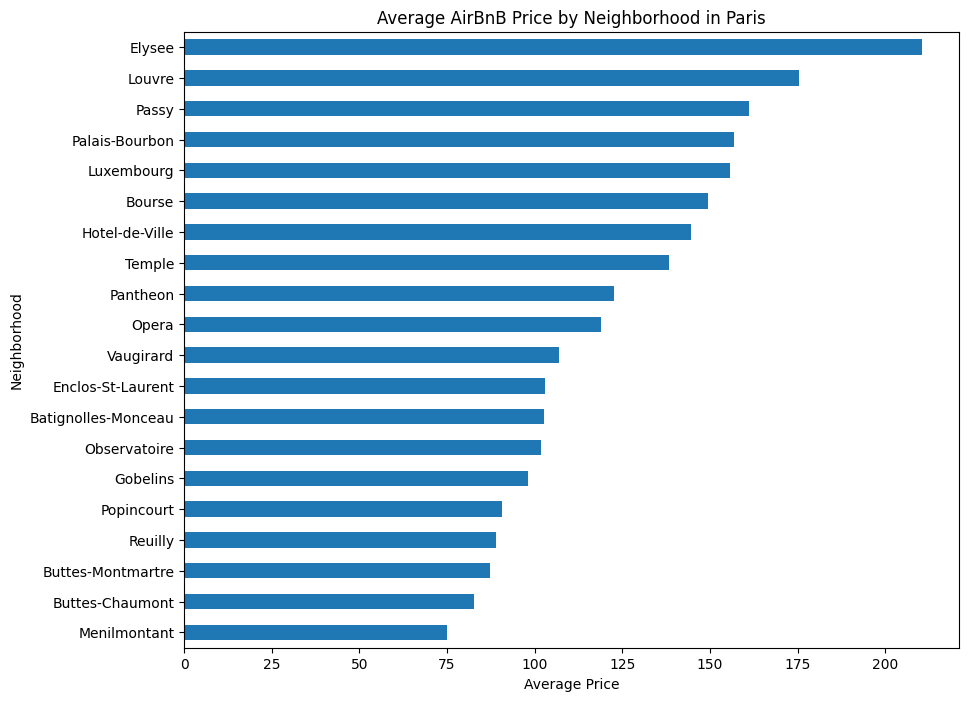

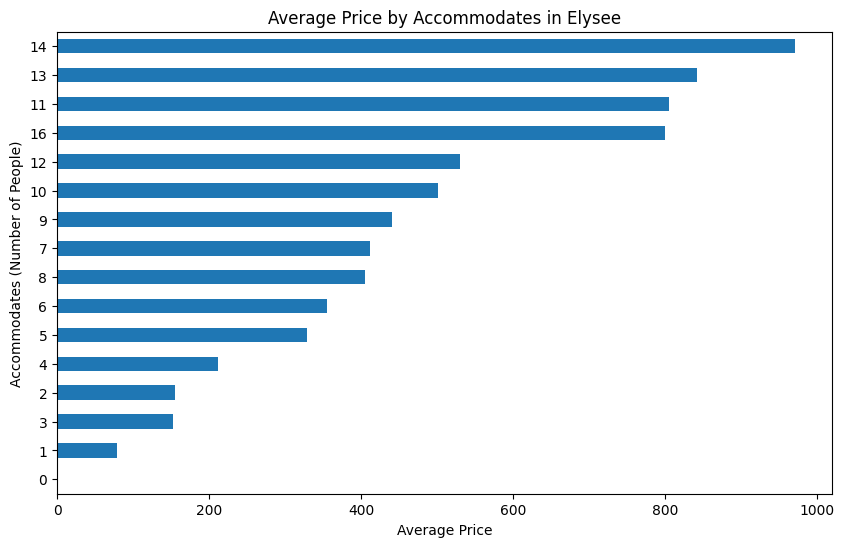

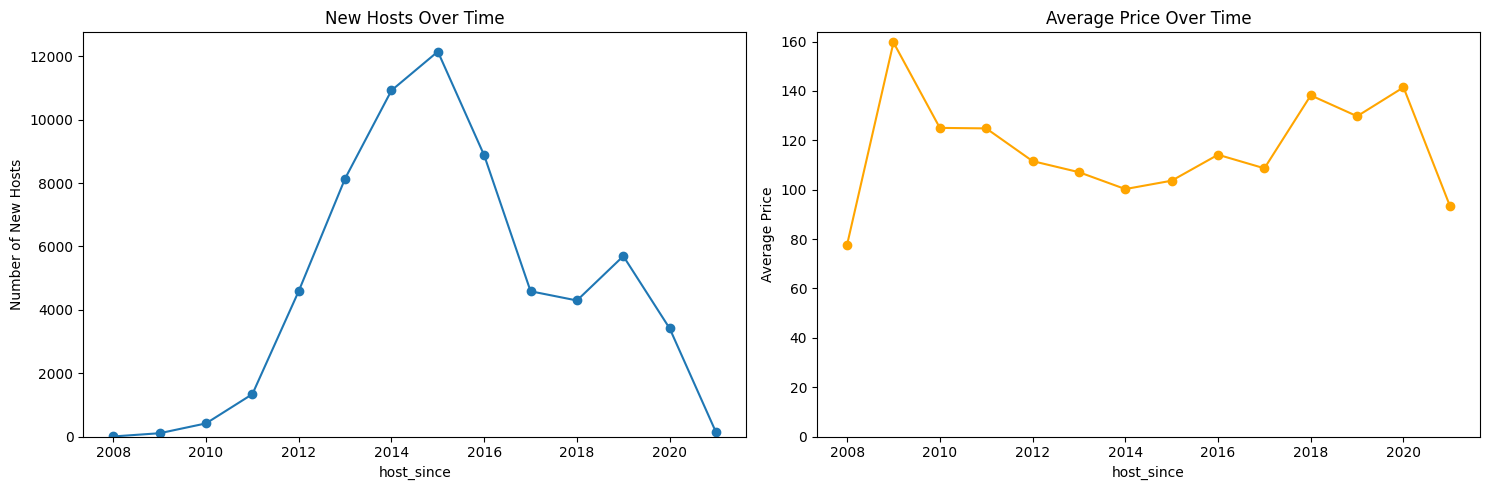

In [16]:
import matplotlib.pyplot as plt

# 1. Horizontal bar chart: Average Price by Neighborhood
plt.figure(figsize=(10, 8))
paris_listings_neighbourhood.plot(kind='barh')
plt.title('Average AirBnB Price by Neighborhood in Paris')
plt.xlabel('Average Price')
plt.ylabel('Neighborhood')
plt.show()

# 2. Horizontal bar chart: Average Price by Accommodates (Most Expensive Neighborhood)
plt.figure(figsize=(10, 6))
paris_listings_accommodations.plot(kind='barh')
plt.title(f'Average Price by Accommodates in {most_expensive_neighbourhood}')
plt.xlabel('Average Price')
plt.ylabel('Accommodates (Number of People)')
plt.show()

# 3. Two-line charts: New Hosts and Average Price Over Time
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Chart A: New Hosts
paris_listings_over_time['new_hosts'].plot(ax=ax[0], title='New Hosts Over Time', marker='o')
ax[0].set_ylim(0)
ax[0].set_ylabel('Number of New Hosts')

# Chart B: Average Price
paris_listings_over_time['price'].plot(ax=ax[1], title='Average Price Over Time', color='orange', marker='o')
ax[1].set_ylim(0)
ax[1].set_ylabel('Average Price')

plt.tight_layout()
plt.show()

Based on the data visualizations, here are the key insights regarding the Paris AirBnB market:

1. The "2015 Regulation" Effect on Host Growth
The chart "New Hosts Over Time" reveals a significant trend. There was a rapid increase in new hosts leading up to 2014, followed by a sharp decline starting in 2015.

Why? In 2015, Paris began implementing strict regulations, including the "120-day rule" and mandatory registration for short-term rentals.

Impact: These legal barriers significantly slowed down the entry of new casual hosts into the market.

2. Price Resilience vs. Supply Drop
While the growth of new hosts slowed down, the "Average Price Over Time" did not drop. In fact, it remained stable or showed a slight upward trend.

Insight: This suggests that while regulations limited the number of new participants, the demand for Parisian rentals remained high, allowing existing hosts to maintain or even increase their prices despite the stricter legal environment.

3. Geographic Pricing Power
The horizontal bar chart for Average Price by Neighborhood identifies Élysée as the most expensive area in Paris.

Insight: The Élysée neighborhood (home to the Champs-Élysées) commands a premium price due to its status as a global luxury and tourism hub. Even with regulations, prime locations maintain high valuation.

4. Capacity as a Price Driver
Looking at the most expensive neighborhood (Élysée), there is a clear correlation between the accommodates value and the price.

Insight: Large-capacity listings (accommodating 4+ people) see a disproportionate increase in price. This indicates that "Luxury Group Travel" is a major revenue driver in central Paris.

------------------------------------------------------------------------------------------------

BONUS: Dual Axis Line Chart

In [ ]:
# Create the figure and the first axis (ax1)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot 'New Hosts' on the first axis
ax1.set_xlabel('Year')
ax1.set_ylabel('New Hosts', color='tab:blue', fontsize=12)
ax1.plot(paris_listings_over_time.index, paris_listings_over_time['new_hosts'], 
         color='tab:blue', marker='o', label='New Hosts')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim(0)

# Create a second axis (ax2) that shares the same x-axis
ax2 = ax1.twinx()  

# Plot 'Average Price' on the second axis
ax2.set_ylabel('Average Price (€)', color='tab:red', fontsize=12)
ax2.plot(paris_listings_over_time.index, paris_listings_over_time['price'], 
         color='tab:red', marker='s', linestyle='--', label='Average Price')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0)

# Add title and grid
plt.title('Paris AirBnB: New Hosts vs. Average Price (Impact of 2015 Regulations)', fontsize=14)
ax1.grid(axis='x', linestyle='--')

plt.show()

Bonus Insight:  
Before 2015: Both new hosts and prices were rising together as the platform grew in popularity.

After 2015: The blue line (New Hosts) drops sharply, while the red line (Price) remains high or continues to climb.

Conclusion: This proves that the regulations successfully limited the entry of new hosts but did not lower the market value of listings in Paris.

------------------------------------------------------------------------------------------------

Final Project Question



Which neighborhood in Paris has the highest average AirBnB listing price?

ANSWER:By grouping the filtered Paris dataset by neighborhood and calculating the mean price, (Elysee) emerged as the most expensive area. This aligns with its real-world status as a high-end district containing the Champs-Élysées. My analysis shows that while 2015 regulations reduced the volume of new hosts, premium locations like Elysee maintained their high valuation due to consistent demand for luxury accommodations.
